In [4]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
# Load the Toyota Corolla dataset

df = pd.read_csv("data/ToyotaCorolla - MLR.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [6]:
# Display the first 5 rows of the dataset

df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [7]:
# Check the structure and data types of the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1436 non-null   int64
 1   Age_08_04  1436 non-null   int64
 2   KM         1436 non-null   int64
 3   Fuel_Type  1436 non-null   str  
 4   HP         1436 non-null   int64
 5   Automatic  1436 non-null   int64
 6   cc         1436 non-null   int64
 7   Doors      1436 non-null   int64
 8   Cylinders  1436 non-null   int64
 9   Gears      1436 non-null   int64
 10  Weight     1436 non-null   int64
dtypes: int64(10), str(1)
memory usage: 123.5 KB


In [8]:
# Check for missing values in each column

df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [9]:
# Display summary statistics for numerical variables

df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [10]:
# Check the unique values in the Fuel_Type column

df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64

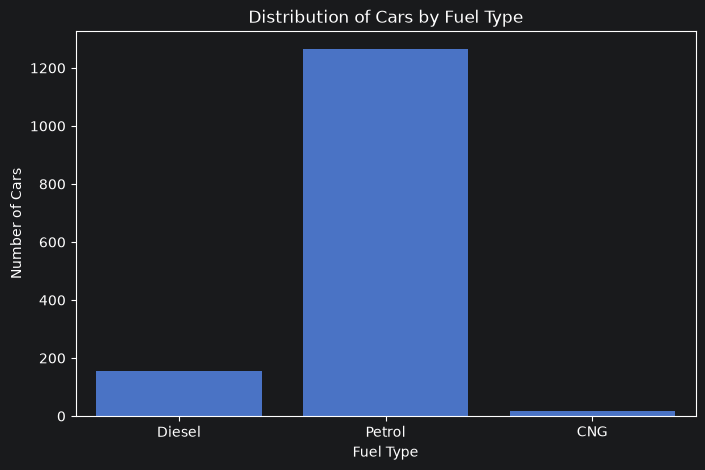

In [11]:
# Visualize the distribution of fuel types

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Fuel_Type")

plt.title("Distribution of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.show()

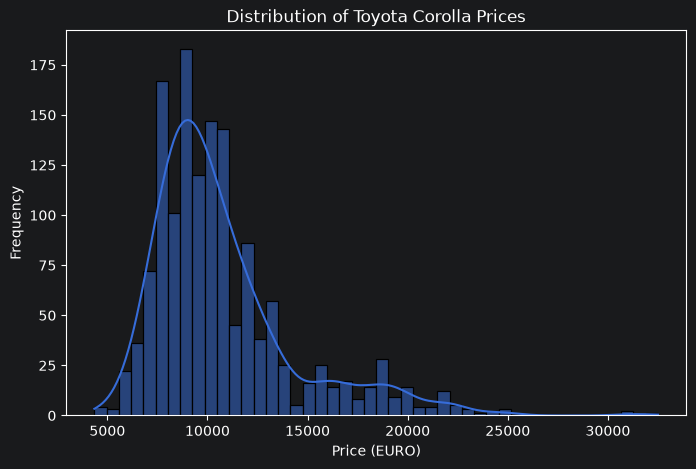

In [12]:
# Visualize the distribution of car prices

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Price", kde=True)

plt.title("Distribution of Toyota Corolla Prices")
plt.xlabel("Price (EURO)")
plt.ylabel("Frequency")
plt.show()

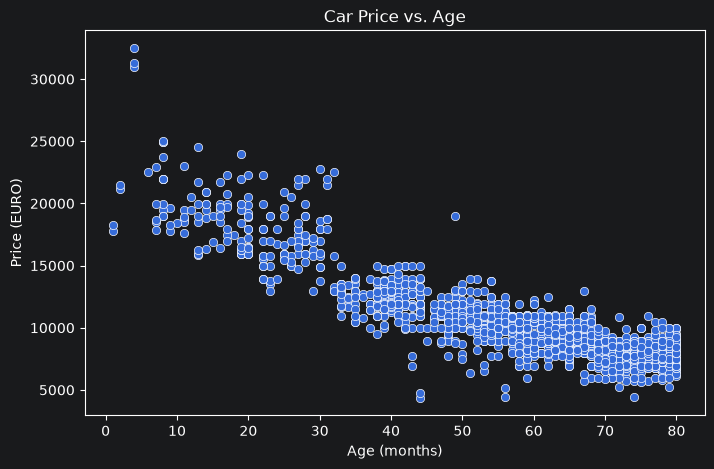

In [13]:
# Visualize the relationship between car age and price

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age_08_04", y="Price")

plt.title("Car Price vs. Age")
plt.xlabel("Age (months)")
plt.ylabel("Price (EURO)")
plt.show()

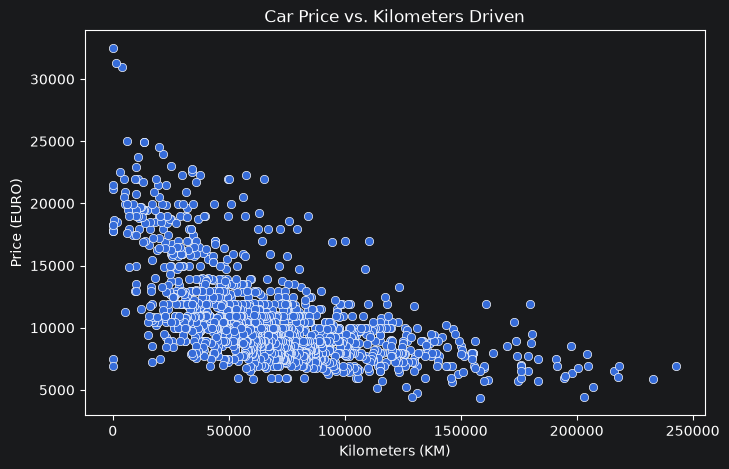

In [14]:
# Visualize the relationship between kilometers driven and price

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="KM", y="Price")

plt.title("Car Price vs. Kilometers Driven")
plt.xlabel("Kilometers (KM)")
plt.ylabel("Price (EURO)")
plt.show()

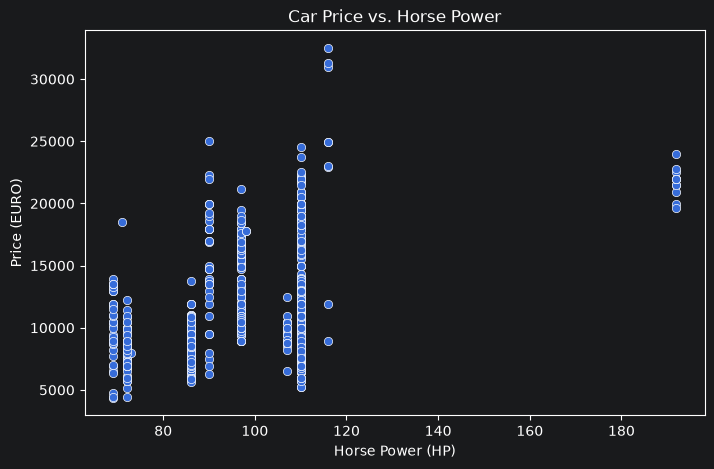

In [15]:
# Visualize the relationship between horsepower and price

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="HP", y="Price")

plt.title("Car Price vs. Horse Power")
plt.xlabel("Horse Power (HP)")
plt.ylabel("Price (EURO)")
plt.show()

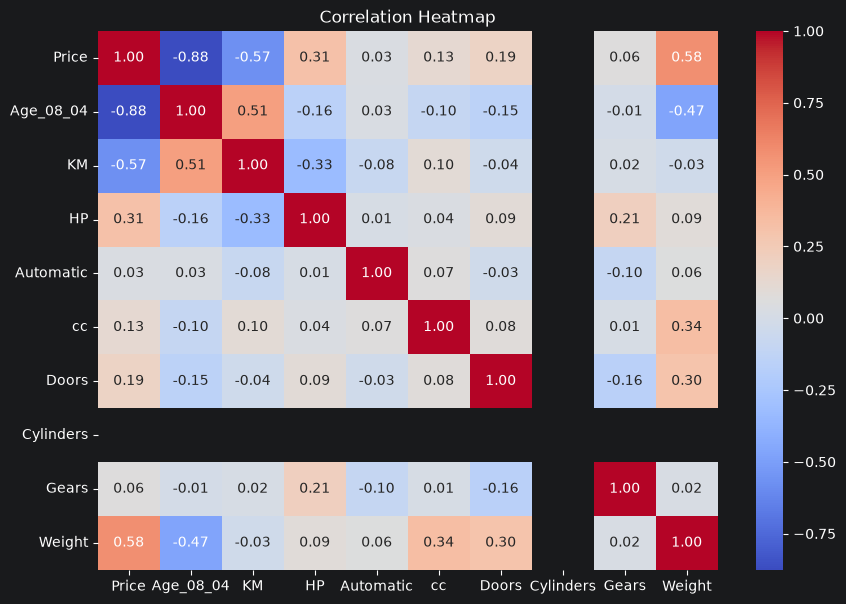

In [16]:
# Display the correlation matrix for numerical variables

plt.figure(figsize=(10, 7))
correlation_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [17]:
# Convert the categorical Fuel_Type variable into numerical variables
# using one-hot encoding

df_encoded = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)

# Display the first 5 rows of the encoded dataset
df_encoded.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [18]:
# Define the independent variables (X) and dependent variable (y)

X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (1436, 11)
Target (y) shape: (1436,)


In [21]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1148, 11)
Testing data: (288, 11)


In [22]:
# Build the first Multiple Linear Regression model

from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

print("Model 1 trained successfully")

Model 1 trained successfully


In [23]:
# Make predictions using Model 1

y_pred_1 = model_1.predict(X_test)

print("Predictions generated successfully")
print(y_pred_1[:5])

Predictions generated successfully
[11137.15453645  8974.9731327   9283.27025955  8951.97440751
 10082.31592852]


In [24]:
# Evaluate Model 1

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_1 = mean_absolute_error(y_test, y_pred_1)
mse_1 = mean_squared_error(y_test, y_pred_1)
rmse_1 = np.sqrt(mse_1)
r2_1 = r2_score(y_test, y_pred_1)

print("Model 1 Performance")
print("--------------------")
print("MAE :", mae_1)
print("MSE :", mse_1)
print("RMSE:", rmse_1)
print("R²  :", r2_1)

Model 1 Performance
--------------------
MAE : 990.8872739193921
MSE : 2203043.8231437
RMSE: 1484.2654153296505
R²  : 0.8348888040611084


In [25]:
# Build Model 2 using selected important predictors

selected_features_2 = [
    "Age_08_04",
    "KM",
    "HP",
    "cc",
    "Weight"
]

X2 = df_encoded[selected_features_2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.20, random_state=42
)

model_2 = LinearRegression()
model_2.fit(X2_train, y2_train)

y_pred_2 = model_2.predict(X2_test)

print("Model 2 trained and predictions generated successfully")

Model 2 trained and predictions generated successfully


In [26]:
# Evaluate Model 2

mae_2 = mean_absolute_error(y2_test, y_pred_2)
mse_2 = mean_squared_error(y2_test, y_pred_2)
rmse_2 = np.sqrt(mse_2)
r2_2 = r2_score(y2_test, y_pred_2)

print("Model 2 Performance")
print("--------------------")
print("MAE :", mae_2)
print("MSE :", mse_2)
print("RMSE:", rmse_2)
print("R²  :", r2_2)

Model 2 Performance
--------------------
MAE : 998.5448804175766
MSE : 1995964.8372853638
RMSE: 1412.7861965935836
R²  : 0.8504087218447196


In [27]:
# Build Model 3 using a different set of predictors

selected_features_3 = [
    "Age_08_04",
    "KM",
    "HP",
    "Weight",
    "Fuel_Type_Diesel",
    "Fuel_Type_Petrol"
]

X3 = df_encoded[selected_features_3]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.20, random_state=42
)

model_3 = LinearRegression()
model_3.fit(X3_train, y3_train)

y_pred_3 = model_3.predict(X3_test)

print("Model 3 trained and predictions generated successfully")

Model 3 trained and predictions generated successfully


In [28]:
# Evaluate Model 3

mae_3 = mean_absolute_error(y3_test, y_pred_3)
mse_3 = mean_squared_error(y3_test, y_pred_3)
rmse_3 = np.sqrt(mse_3)
r2_3 = r2_score(y3_test, y_pred_3)

print("Model 3 Performance")
print("--------------------")
print("MAE :", mae_3)
print("MSE :", mse_3)
print("RMSE:", rmse_3)
print("R²  :", r2_3)

Model 3 Performance
--------------------
MAE : 1001.2769680087102
MSE : 2216120.6408840427
RMSE: 1488.6640456745245
R²  : 0.8339087377576149


In [29]:
# Compare the performance of all three models

model_comparison = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "MAE": [mae_1, mae_2, mae_3],
    "MSE": [mse_1, mse_2, mse_3],
    "RMSE": [rmse_1, rmse_2, rmse_3],
    "R2": [r2_1, r2_2, r2_3]
})

model_comparison

,Model,MAE,MSE,RMSE,R2
0,Model 1,990.887274,2.203044e+06,1484.265415,0.834889
1,Model 2,998.544880,1.995965e+06,1412.786197,0.850409
2,Model 3,1001.276968,2.216121e+06,1488.664046,0.833909


In [30]:
# Display the coefficients of Model 1

coefficients_1 = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model_1.coef_
})

coefficients_1

,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,-6.679102e-13
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


In [31]:
# Calculate residuals for Model 1

residuals_1 = y_test - y_pred_1

print("Residuals calculated successfully")
print(residuals_1.head())

Residuals calculated successfully
594     -337.154536
754      975.026867
630    -1783.270260
1259     298.025592
903     -332.315929
Name: Price, dtype: float64


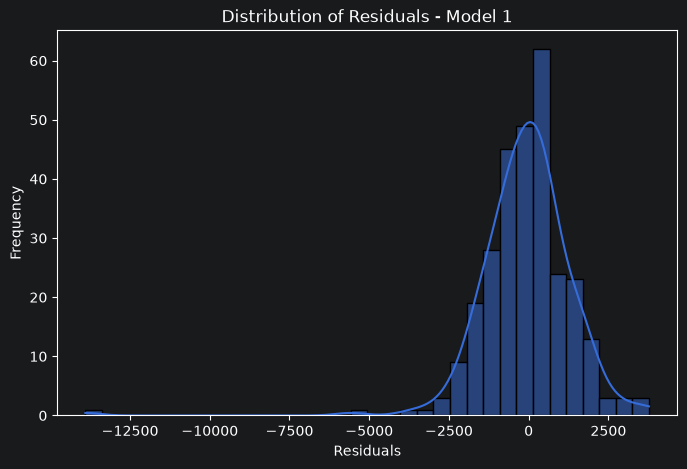

In [32]:
# Visualize the distribution of residuals

plt.figure(figsize=(8, 5))
sns.histplot(residuals_1, kde=True)

plt.title("Distribution of Residuals - Model 1")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

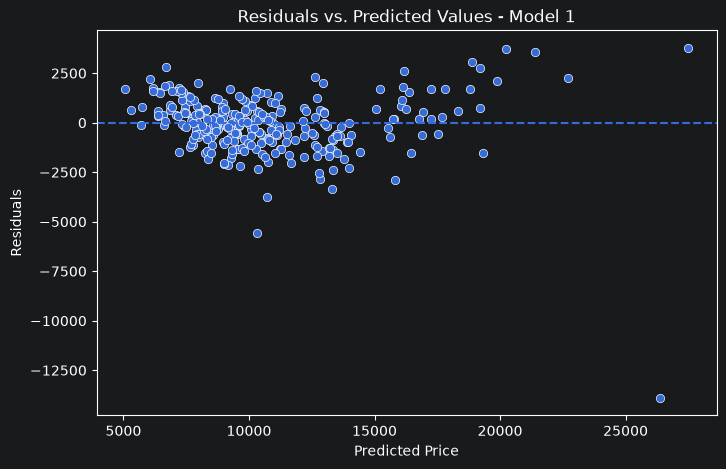

In [33]:
# Plot residuals against predicted values

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_1, y=residuals_1)

plt.axhline(y=0, linestyle="--")
plt.title("Residuals vs. Predicted Values - Model 1")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.show()

In [34]:
# Import Ridge and Lasso regression

from sklearn.linear_model import Ridge, Lasso

# Create Ridge and Lasso models
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=1.0)

# Train both models
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Generate predictions
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

print("Ridge and Lasso models trained successfully")

Ridge and Lasso models trained successfully


In [35]:
# Evaluate Ridge and Lasso regression models

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Ridge Regression Performance")
print("----------------------------")
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R²  :", r2_ridge)

print("\nLasso Regression Performance")
print("----------------------------")
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE:", rmse_lasso)
print("R²  :", r2_lasso)

Ridge Regression Performance
----------------------------
MAE : 990.7338342026002
MSE : 2199746.370233344
RMSE: 1483.1541963778898
R²  : 0.8351359377712333

Lasso Regression Performance
----------------------------
MAE : 990.9546616159033
MSE : 2195387.2460865397
RMSE: 1481.6839224634043
R²  : 0.8354626403967389


In [36]:
# Compare all five regression models

final_comparison = pd.DataFrame({
    "Model": [
        "Model 1 - MLR",
        "Model 2 - Selected Features",
        "Model 3 - Selected Features + Fuel",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        mae_1,
        mae_2,
        mae_3,
        mae_ridge,
        mae_lasso
    ],
    "MSE": [
        mse_1,
        mse_2,
        mse_3,
        mse_ridge,
        mse_lasso
    ],
    "RMSE": [
        rmse_1,
        rmse_2,
        rmse_3,
        rmse_ridge,
        rmse_lasso
    ],
    "R2": [
        r2_1,
        r2_2,
        r2_3,
        r2_ridge,
        r2_lasso
    ]
})

final_comparison


,Model,MAE,MSE,RMSE,R2
0,Model 1 - MLR,990.887274,2.203044e+06,1484.265415,0.834889
1,Model 2 - Selected Features,998.544880,1.995965e+06,1412.786197,0.850409
2,Model 3 - Selected Features + Fuel,1001.276968,2.216121e+06,1488.664046,0.833909
3,Ridge Regression,990.733834,2.199746e+06,1483.154196,0.835136
4,Lasso Regression,990.954662,2.195387e+06,1481.683922,0.835463


In [37]:
# Final model conclusion

print("Best Model: Model 2 - Selected Features")
print("R² Score:", r2_2)
print("RMSE:", rmse_2)
print("MAE:", mae_2)

print("\nModel 2 provides the best prediction performance")
print("among the models evaluated in this analysis.")

Best Model: Model 2 - Selected Features
R² Score: 0.8504087218447196
RMSE: 1412.7861965935836
MAE: 998.5448804175766

Model 2 provides the best prediction performance
among the models evaluated in this analysis.


In [ ]:
## Interview Question 1: What is Normalization & Standardization and how is it helpful?

**Normalization** is the process of scaling numerical values to a fixed range, usually between 0 and 1. A common formula is:

Normalization = (X - Xmin) / (Xmax - Xmin)

**Standardization** transforms numerical variables so that they have a mean of 0 and a standard deviation of 1. The formula is:

Standardization = (X - Mean) / Standard Deviation

Both techniques are useful when predictor variables have very different scales. For example, in this dataset, variables such as KM, HP, CC, and Weight have different ranges.

Scaling can improve the performance and stability of machine-learning algorithms, particularly regularization methods such as **Ridge and Lasso regression**. It also ensures that variables with larger numerical scales do not disproportionately influence the regularization process.

For ordinary Multiple Linear Regression, scaling is not strictly required for obtaining predictions, but it can make coefficient comparisons and numerical optimization easier.
